# 04 - Análise descritiva dos resultados

Carrega o CSV bruto gerado por `python -m src.pipeline.run_all` e produz:
1. Tabela-resumo com média e desvio das métricas por modelo.
2. Gráfico de barras da métrica principal (AUC OVO).
3. Boxplot da métrica por modelo.
4. Análise por regime (tamanho, número de classes, proporção categórica, missing).
5. Custo computacional vs. desempenho.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path('..').resolve()))

import pandas as pd

from data.load_tabarena import summarize, RECOMMENDED_TASK_IDS
from src.reports.results_table import summary_by_model
from src.reports.plots import (
    bar_metric_by_model,
    boxplot_metric_by_model,
    bar_metric_by_regime,
    time_vs_quality,
)
from src.pipeline.regime import assign_regimes

In [2]:
raw = pd.read_csv('../results/raw.csv')
raw.head()

,task_id,dataset,model,split,auc_ovo,accuracy,g_mean,cross_entropy,fit_time_s,predict_time_s,total_time_s
0,37,diabetes,lightgbm,test,0.839259,0.757576,0.688769,0.470954,0.547044,0.008628,0.555672
1,37,diabetes,lightgbm,train,0.892605,0.821229,0.776862,0.404559,0.067345,0.008068,0.075413
2,37,diabetes,xgboost,test,0.811605,0.735931,0.675497,1.803288,2.456464,0.062665,2.519129
3,37,diabetes,xgboost,train,0.986394,0.968343,0.961791,0.257595,1.922115,0.051655,1.973770
4,37,diabetes,catboost,test,0.823457,0.731602,0.651683,0.918308,2.445247,0.005649,2.450896


In [14]:
raw['model'] = raw['model'].replace('group_model', 'xrfm')

## 1. Tabela-resumo por modelo

In [15]:
raw_test = raw[raw['split'] == 'test']
raw_train = raw[raw['split'] == 'train']

In [16]:
print("=== DESEMPENHO NO TESTE ===")
summary_test = summary_by_model(raw_test)
display(summary_test)

=== DESEMPENHO NO TESTE ===


,model,auc_ovo_mean,auc_ovo_std,accuracy_mean,accuracy_std,g_mean_mean,g_mean_std,cross_entropy_mean,cross_entropy_std,total_time_s_mean,total_time_s_std
2,xgboost,0.924137,0.094759,0.891286,0.087728,0.820334,0.143259,0.417508,0.543155,10.750288,19.371322
0,catboost,0.921606,0.099522,0.881579,0.091373,0.795505,0.161584,0.349471,0.287971,4.659867,4.708638
3,xrfm,0.904243,0.107737,0.869587,0.099167,0.741508,0.236695,0.368449,0.213597,9.267020,19.259190
1,lightgbm,0.883938,0.164731,0.878029,0.091121,0.732768,0.310570,0.322378,0.233556,1.710312,3.330370


In [17]:
print("\n=== DESEMPENHO NO TREINO ===")
raw_train = raw[raw['split'] == 'train']
summary_train = summary_by_model(raw_train)
display(summary_train)


=== DESEMPENHO NO TREINO ===


,model,auc_ovo_mean,auc_ovo_std,accuracy_mean,accuracy_std,g_mean_mean,g_mean_std,cross_entropy_mean,cross_entropy_std,total_time_s_mean,total_time_s_std
3,xrfm,0.990907,0.016591,0.967553,0.029822,0.942774,0.054922,0.094632,0.070070,9.860170,20.310049
2,xgboost,0.981425,0.030243,0.965005,0.040843,0.924738,0.109518,0.125071,0.108227,10.591085,20.560982
0,catboost,0.978272,0.030437,0.965316,0.036708,0.922673,0.111863,0.118516,0.095501,4.439603,4.704876
1,lightgbm,0.904605,0.164744,0.912624,0.080625,0.777171,0.318380,0.261442,0.227884,1.864072,3.874176


## 2. Gráfico de barras (AUC OVO)

### Treino

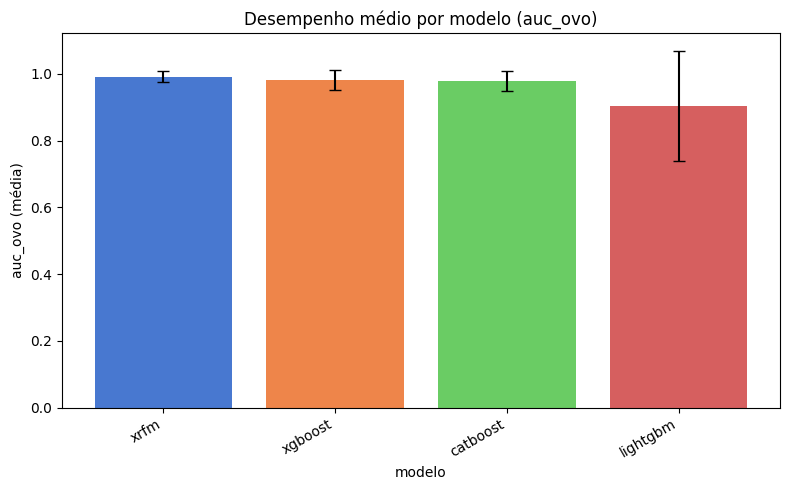

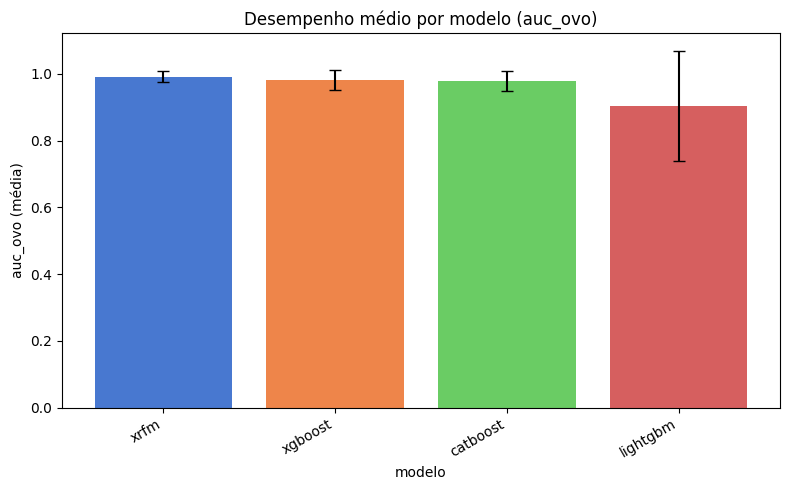

In [18]:
fig = bar_metric_by_model(raw_train, metric='auc_ovo', output_path=Path('../results/figures/bar_auc.png'))
fig

### Teste

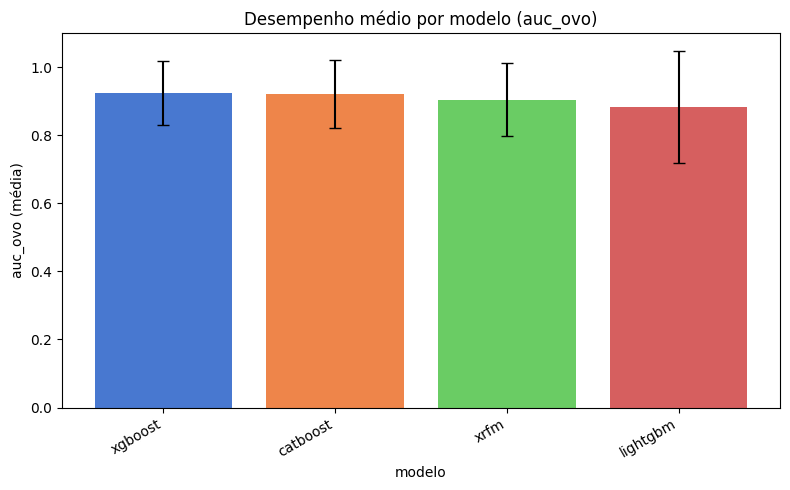

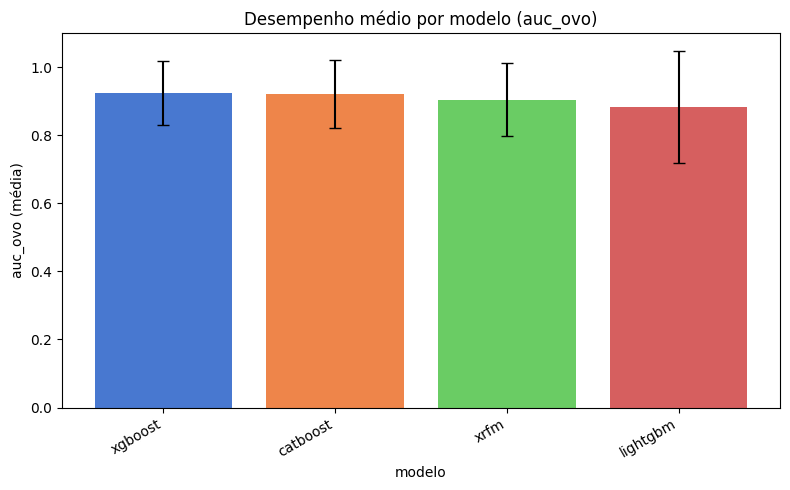

In [20]:
fig = bar_metric_by_model(raw_test, metric='auc_ovo', output_path=Path('../results/figures/bar_auc.png'))
fig

## 3. Boxplot por modelo

### Treino

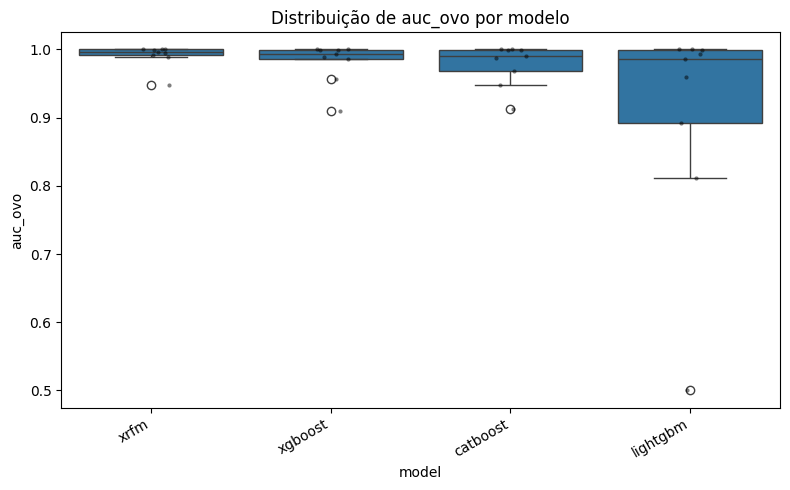

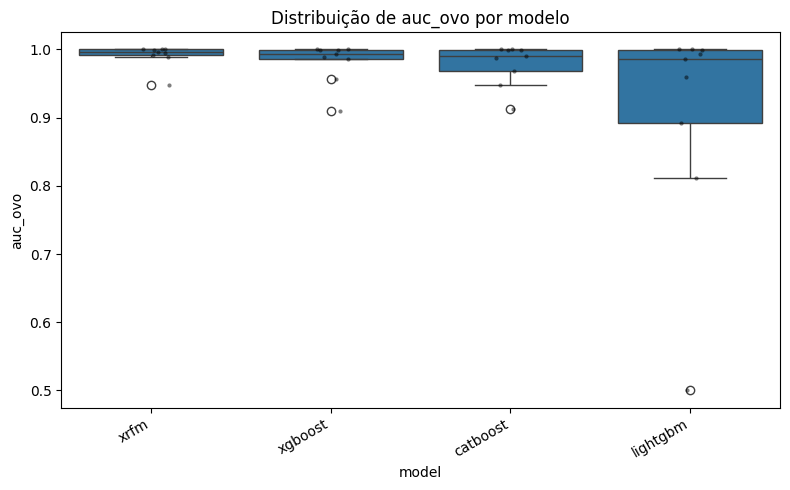

In [21]:
fig = boxplot_metric_by_model(raw_train, metric='auc_ovo', output_path=Path('../results/figures/box_auc.png'))
fig

### Teste

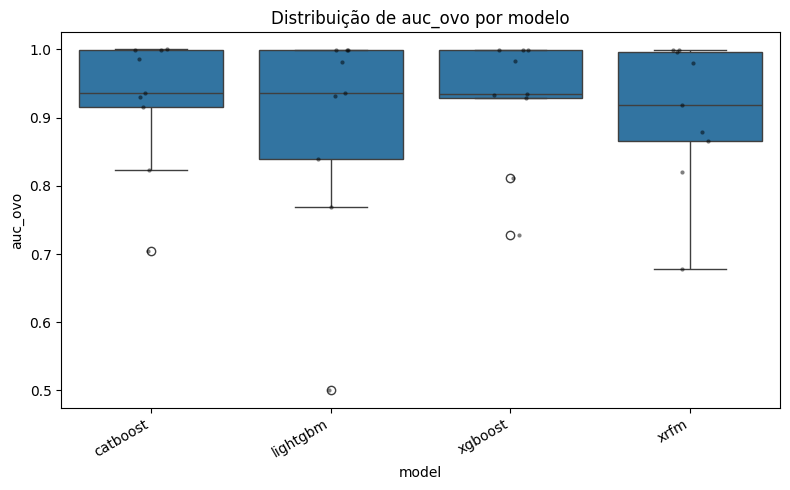

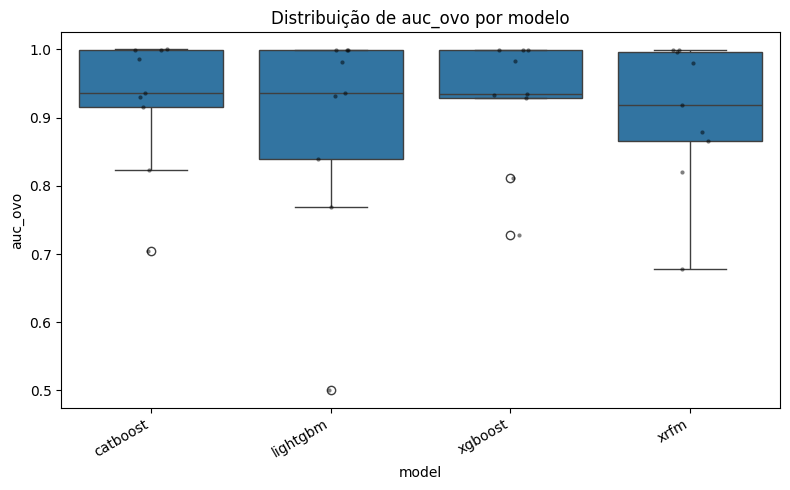

In [22]:
fig = boxplot_metric_by_model(raw_test, metric='auc_ovo', output_path=Path('../results/figures/box_auc.png'))
fig

## 4. Análise por regime

In [6]:
metadata = assign_regimes(summarize(RECOMMENDED_TASK_IDS))
metadata

,task_id,name,n_samples,n_features,n_classes,n_categorical,has_missing,regime,regime_size,regime_classes,regime_cat_share,regime_missing
0,37,diabetes,768,8,2,0,False,small,small,binary,low,no
1,10101,blood-transfusion-service-center,748,4,2,0,False,small,small,binary,low,no
2,54,hepatitis,155,19,2,13,True,small,small,binary,high,yes
3,14,mfeat-fourier,2000,76,10,0,False,medium,medium,multiclass,low,no
4,3,kr-vs-kp,3196,36,2,36,False,medium,medium,binary,high,no
5,21,car,1728,6,4,6,False,medium,medium,multiclass,high,no
6,3954,MagicTelescope,19020,10,2,0,False,large,large,binary,low,no
7,14965,bank-marketing,45211,16,2,9,False,large,large,binary,high,no
8,6,letter,20000,16,26,0,False,large,large,multiclass,low,no


### Treino

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_3504\1521433979.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_3504\1521433979.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_3504\1521433979.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_3504\1521433979.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


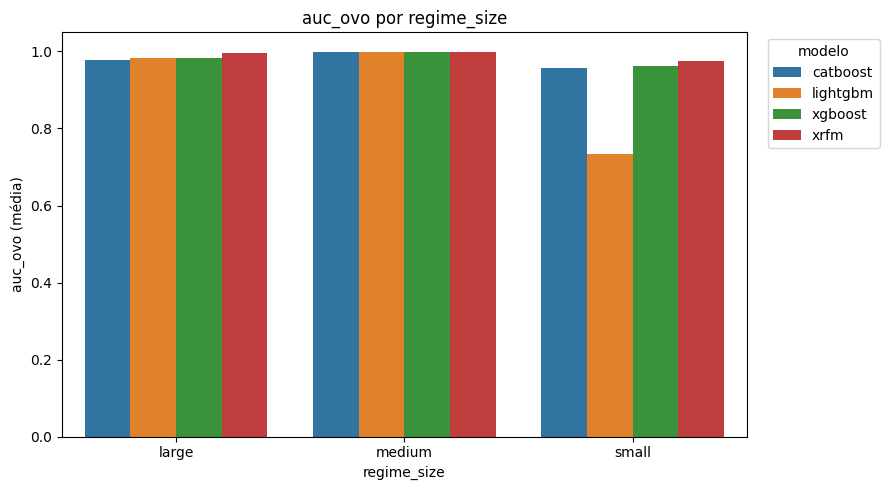

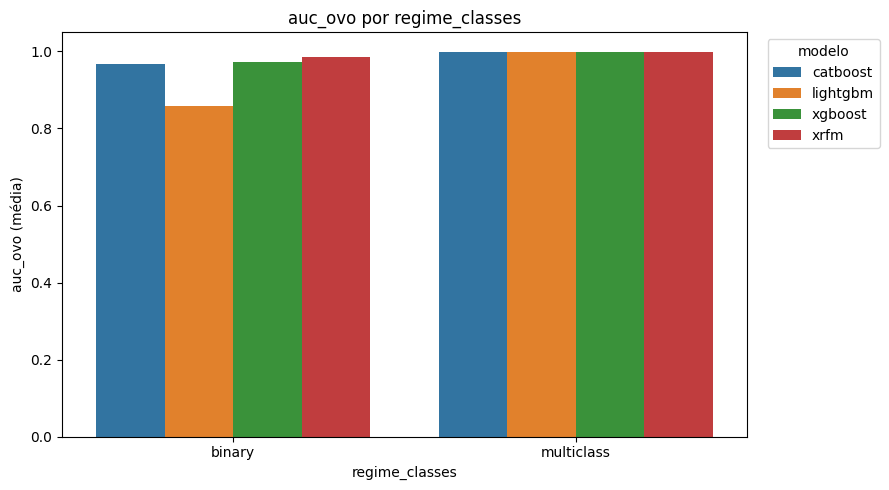

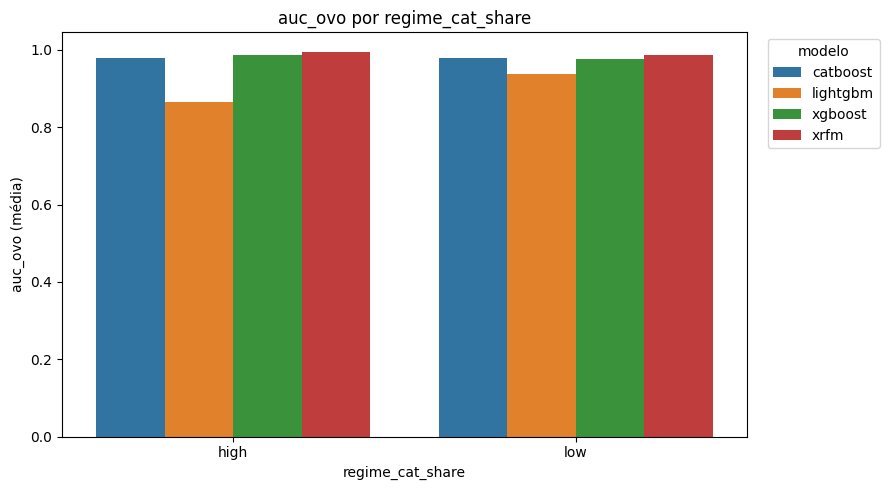

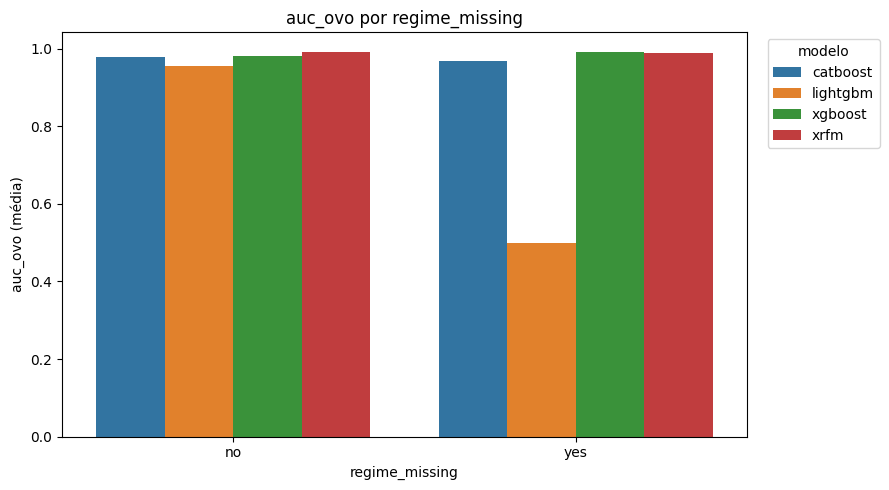

In [23]:
for col in ['regime_size', 'regime_classes', 'regime_cat_share', 'regime_missing']:
    fig = bar_metric_by_regime(
        raw_train, metadata, regime_col=col, metric='auc_ovo',
        output_path=Path(f'../results/figures/regime_{col}.png'),
    )
    fig.suptitle('')
    fig.show()

### Teste

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_3504\875608635.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_3504\875608635.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_3504\875608635.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_3504\875608635.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


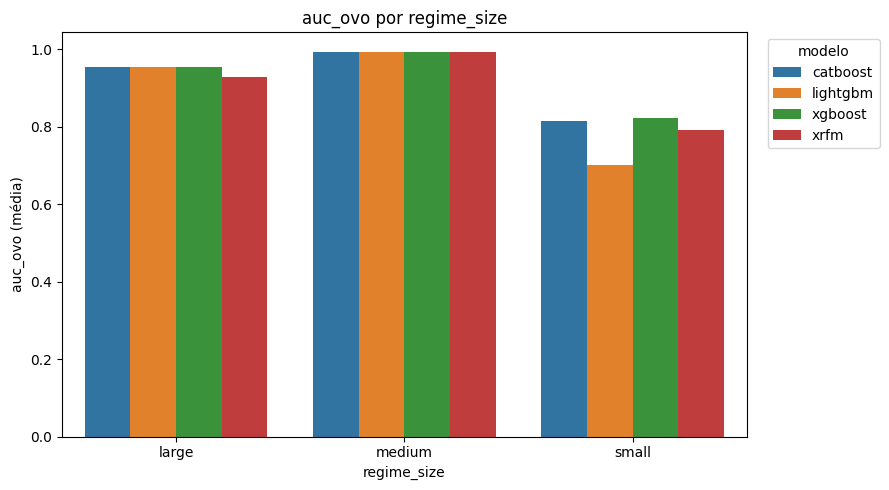

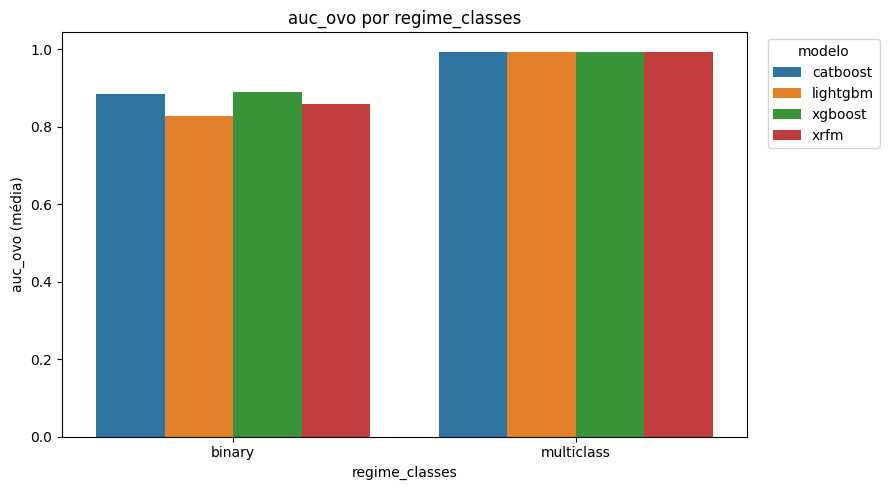

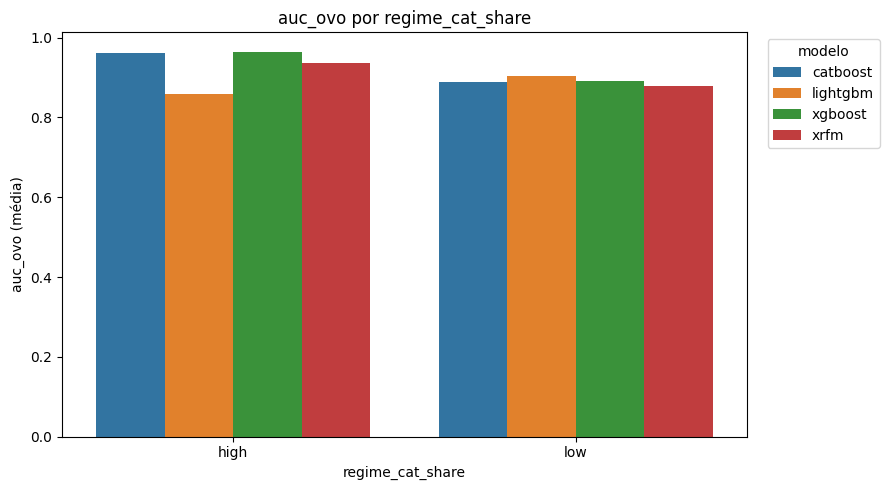

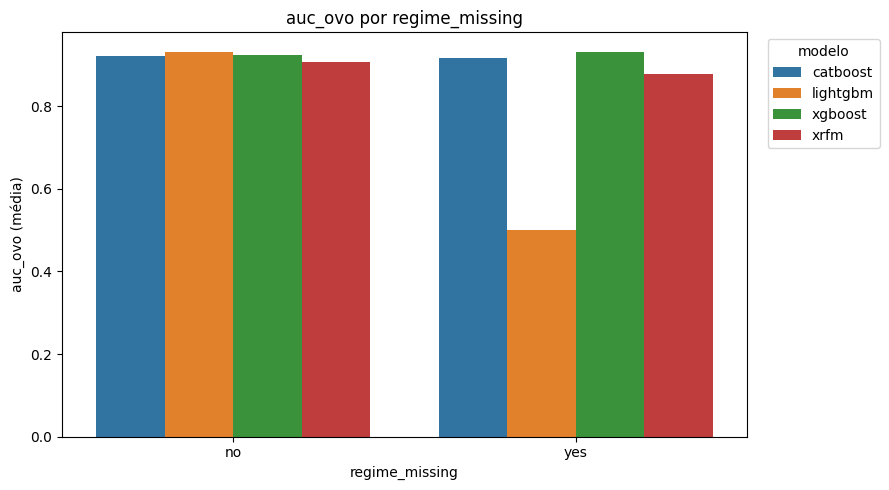

In [24]:
for col in ['regime_size', 'regime_classes', 'regime_cat_share', 'regime_missing']:
    fig = bar_metric_by_regime(
        raw_test, metadata, regime_col=col, metric='auc_ovo',
        output_path=Path(f'../results/figures/regime_{col}.png'),
    )
    fig.suptitle('')
    fig.show()

## 5. Custo computacional vs. desempenho

### Treino

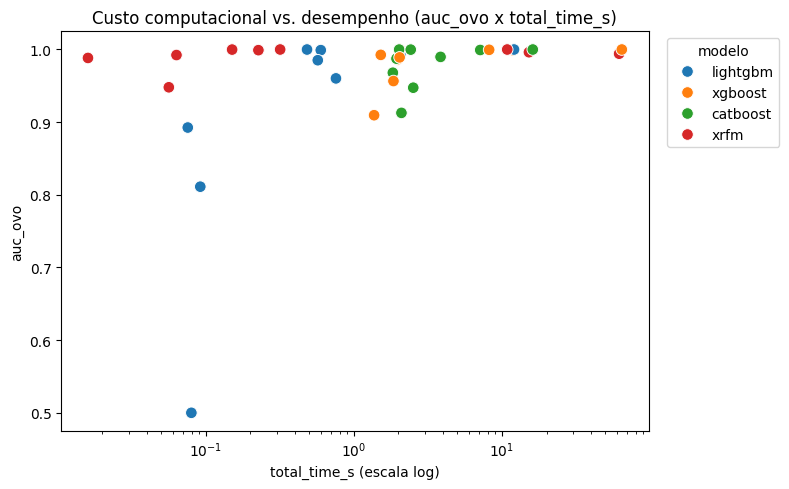

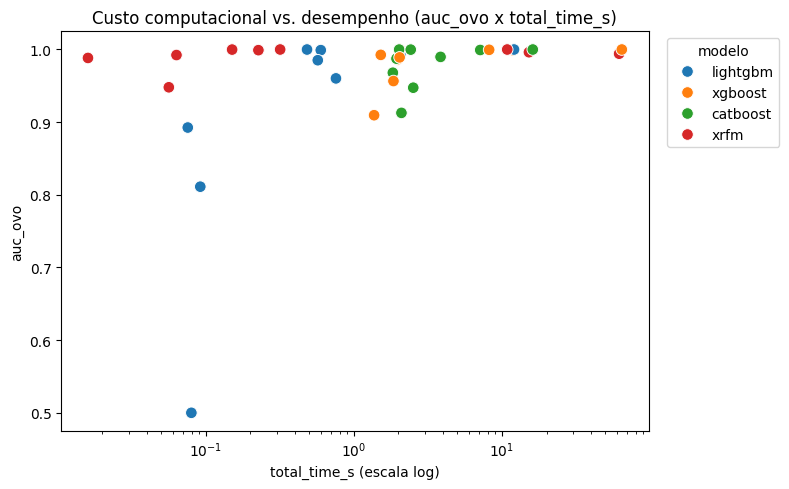

In [25]:
fig = time_vs_quality(raw_train, x='total_time_s', y='auc_ovo', output_path=Path('../results/figures/time_vs_quality.png'))
fig

### Teste

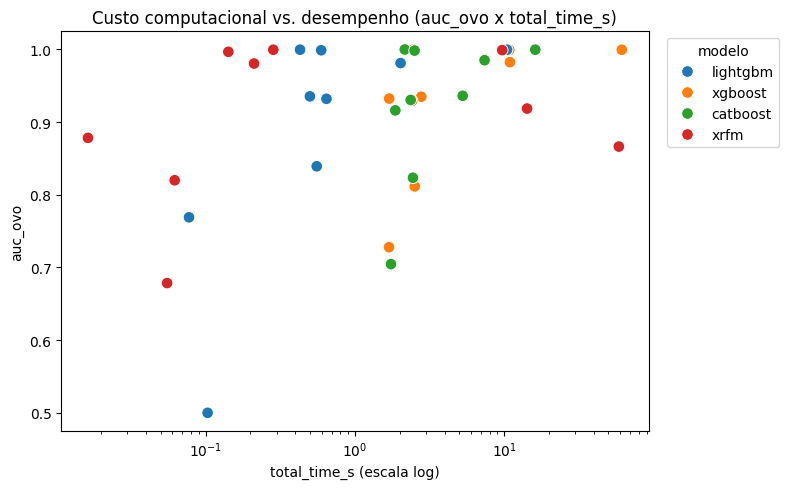

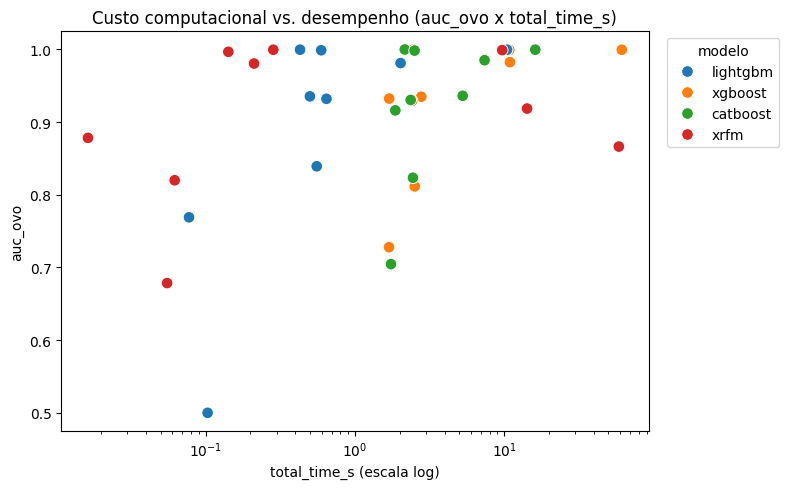

In [26]:
fig = time_vs_quality(raw_test, x='total_time_s', y='auc_ovo', output_path=Path('../results/figures/time_vs_quality.png'))
fig